In [ ]:
import pandas as _hex_pandas
import datetime as _hex_datetime
import json as _hex_json

In [ ]:
hex_scheduled = _hex_json.loads("false")

In [ ]:
hex_user_email = _hex_json.loads("\"example-user@example.com\"")

In [ ]:
hex_user_attributes = _hex_json.loads("{}")

In [ ]:
hex_run_context = _hex_json.loads("\"logic\"")

In [ ]:
hex_timezone = _hex_json.loads("\"UTC\"")

In [ ]:
hex_project_id = _hex_json.loads("\"019e3289-f3d1-7000-91a8-06caef9993c7\"")

In [ ]:
hex_project_name = _hex_json.loads("\"TTC  Delay Analysis\"")

In [ ]:
hex_status = _hex_json.loads("\"\"")

In [ ]:
hex_categories = _hex_json.loads("[]")

In [ ]:
hex_color_palette = _hex_json.loads("[\"#4C78A8\",\"#F58518\",\"#E45756\",\"#72B7B2\",\"#54A24B\",\"#EECA3B\",\"#B279A2\",\"#FF9DA6\",\"#9D755D\",\"#BAB0AC\"]")

Having lived in Canada for the past 5 years, one thing I’ve heard and experienced over and over again is how unreliable the TTC is. So I decided to take a look at the data myself to better understand why delays happen, and which parts of the TTC network cause riders the most trouble. 



1. **Data Preparation**



Before starting the analysis, the raw TTC datasets first needed to be cleaned and standardized.

I downloaded the TTC bus, streetcar, and subway delay datasets from the City of Toronto Open Data Portal.

From there, I combined the three datasets into a single 2025 incident-level dataset. Rows from 2026 were removed, along with incidents that did not cause any delay, since the focus of this project was on actual delay-causing events.

I then standardized column names and location fields, converted date/time variables, removed unused columns, and added features used throughout the analysis, including:

- hour of day 
- month and season 
- weekday/weekend indicators 
- transit mode labels 

Because location names were messy free-text fields with inconsistent spelling, abbreviations, and formatting, I also created a `location_clean` field to standardize naming and merge equivalent locations. However, after testing, the results were still fairly inconsistent, and fully cleaning the location data would have required significantly more work than was justified for the goals of this analysis.

Basic data quality checks were also performed for missing values, duplicates, and invalid delay values.



In [ ]:
# Load raw data
# Read the three TTC delay datasets (bus, streetcar, subway) as separate DataFrames.
import pandas as pd
import numpy as np

bus_raw       = pd.read_csv("TTC Bus Delay Data since 2025.csv")
streetcar_raw = pd.read_csv("TTC Streetcar Delay Data since 2025.csv")
subway_raw    = pd.read_csv("TTC Subway Delay Data since 2025.csv")

# Combine the three dataframes into a single list for processing
column_map = {
    "_id":       "id",
    "Date":      "date",
    "Time":      "time",
    "Day":       "day",
    "Line":      "line",
    "Station":   "location", 
    "Code":      "code",
    "Min Delay": "min_delay",
    "Min Gap":   "min_gap",
    "Bound":     "bound",
    "Vehicle":   "vehicle",
}

def standardize(df, mode):
    """Rename columns to the clean schema and tag the mode of transport."""
    df = df.rename(columns=column_map).copy()
    df["mode"] = mode
    return df

bus       = standardize(bus_raw,       "Bus")
streetcar = standardize(streetcar_raw, "Streetcar")
subway    = standardize(subway_raw,    "Subway")

# Stack into one table
TTC_delays_2025 = pd.concat([bus, streetcar, subway], ignore_index=True)

# Sanity Check
# print(f"Combined raw table: {TTC_delays_2025.shape[0]:,} rows, {TTC_delays_2025.shape[1]} columns")
# print(f"Rows by mode:\n{TTC_delays_2025['mode'].value_counts()}")

# Convert date and time columns to datetime objects
TTC_delays_2025["date"] = pd.to_datetime(
    TTC_delays_2025["date"], format="ISO8601", errors="coerce"
)

TTC_delays_2025["hour"] = pd.to_datetime(
    TTC_delays_2025["time"], format="%H:%M", errors="coerce"
).dt.hour

# Sanity Check
# n_bad_date = TTC_delays_2025["date"].isna().sum()
# n_bad_time = TTC_delays_2025["hour"].isna().sum()
# print(f"Rows with unparseable date: {n_bad_date}")
#print(f"Rows with unparseable time: {n_bad_time}")
 
# Filter out 2026 data
before = len(TTC_delays_2025)
TTC_delays_2025 = TTC_delays_2025[TTC_delays_2025["date"].dt.year == 2025].copy()
after = len(TTC_delays_2025)

# Filter out all 0 delay incidents
TTC_delays_2025 = TTC_delays_2025[TTC_delays_2025["min_delay"] > 0].copy()

# Filter out columns not used in analysis
TTC_delays_2025 = TTC_delays_2025.drop(columns=["min_gap", "bound"])

# Location Cleaning
def clean_location(s: str) -> str:
    if pd.isna(s) or s == "":
        return ""
    s = s.upper().replace("&", "AND")
    s = " ".join(s.split())
    return " ".join(sorted(s.split(" ")))

TTC_delays_2025["location_clean"] = TTC_delays_2025["location"].apply(clean_location)

# Data Quality Checks
quality_checks = []

# 1. Missing values per column
missing = TTC_delays_2025.isna().sum()
for col, n in missing[missing > 0].items():
    quality_checks.append({
        "check": f"Missing values: '{col}'",
        "result": f"{n:,} rows ({100*n/len(TTC_delays_2025):.2f}%)",
        "action": "Reported; handled per-column as needed downstream",
    })

# 2. Exact duplicate rows
dups = TTC_delays_2025.duplicated().sum()
quality_checks.append({
    "check": "Exact duplicate rows",
    "result": f"{dups:,} found",
    "action": "Dropped" if dups > 0 else "None — no action needed",
})


# 3. Negative or implausible delay values
bad_delay = (TTC_delays_2025["min_delay"] < 0).sum()
quality_checks.append({
    "check": "Negative delay values",
    "result": f"{bad_delay:,} rows",
    "action": "Dropped" if bad_delay > 0 else "None — no action needed",
})

# Drop exact duplicates if any were found.
if dups > 0:
    TTC_delays_2025 = TTC_delays_2025.drop_duplicates().copy()

quality_report = pd.DataFrame(quality_checks)
quality_report

# Month,Season and Weekend Columns
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
day_order   = ["Monday", "Tuesday", "Wednesday", "Thursday",
               "Friday", "Saturday", "Sunday"]

TTC_delays_2025["month"]      = TTC_delays_2025["date"].dt.month
TTC_delays_2025["month_name"] = pd.Categorical(
    TTC_delays_2025["date"].dt.month_name(), categories=month_order, ordered=True)
TTC_delays_2025["day"]        = pd.Categorical(
    TTC_delays_2025["day"], categories=day_order, ordered=True)
TTC_delays_2025["is_weekend"] = TTC_delays_2025["day"].isin(["Saturday", "Sunday"])

# Season from month.
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}
TTC_delays_2025["season"] = pd.Categorical(
    TTC_delays_2025["month"].map(season_map),
    categories=["Winter", "Spring", "Summer", "Fall"], ordered=True)

TTC_delays_2025.head()

,id,date,line,time,day,location,code,min_delay,vehicle,mode,hour,location_clean,month,month_name,is_weekend,season
0,1,2025-01-01,102 MARKHAM ROAD,02:15,Wednesday,WARDEN STATION,MFESA,20,3442,Bus,2,STATION WARDEN,1,January,False,Winter
3,4,2025-01-01,100 FLEMINGDON PARK,02:43,Wednesday,OVERLEA AND THORNCLIFF,MFSAN,17,8693,Bus,2,AND OVERLEA THORNCLIFF,1,January,False,Winter
4,5,2025-01-01,34 EGLINTON EAST,03:05,Wednesday,EGLINTON AND DON MILLS,MFUI,20,8801,Bus,3,AND DON EGLINTON MILLS,1,January,False,Winter
7,8,2025-01-01,320 YONGE,03:23,Wednesday,YONGE AND SHUTER,MFSAN,5,3468,Bus,3,AND SHUTER YONGE,1,January,False,Winter
9,10,2025-01-01,39 FINCH EAST,04:38,Wednesday,FINCH AND MCCOWAN,EFO,16,3144,Bus,4,AND FINCH MCCOWAN,1,January,False,Winter


**2. First Date**



Before looking at detailed time, geography, or cause patterns, I wanted a high-level understanding of what the TTC delay dataset actually looks like across each transit mode. As my statistics professor liked to say: _before any serious analysis, you should first go on a date with your data._

This section focuses on the basic structure of delays across buses, streetcars, and subways:

- how much delay each mode generates 
- how modes differ in frequency of incidents vs severity
- which mode appears to be most troublesome to riders



In [ ]:

def count_vehicles(s):
    return s[s != 0].nunique()

summary = (
    TTC_delays_2025
    .groupby("mode")
    .agg(
        num_routes        = ("line",           "nunique"),
        num_locations     = ("location_clean", "nunique"),
        num_vehicles      = ("vehicle",        count_vehicles),
        incidents         = ("id",             "count"),
        total_delay_hours = ("min_delay",      lambda s: round(s.sum() / 60, 1)),
        median_delay_min  = ("min_delay",      "median"),
    )
)

# Sum across modes — used as the denominator so percentages add to 100.
total_routes    = summary["num_routes"].sum()
total_locations = summary["num_locations"].sum()
total_vehicles  = summary["num_vehicles"].sum()
total_incidents = summary["incidents"].sum()

summary["pct_routes"]            = (100 * summary["num_routes"]    / total_routes).round(1)
summary["pct_locations"]         = (100 * summary["num_locations"] / total_locations).round(1)
summary["pct_vehicles"]          = (100 * summary["num_vehicles"]  / total_vehicles).round(1)
summary["pct_incidents"]         = (100 * summary["incidents"]     / total_incidents).round(1)
summary["incidents_per_route"]   = (summary["incidents"] / summary["num_routes"]).round(1)
summary["incidents_per_vehicle"] = (summary["incidents"] / summary["num_vehicles"]).round(1)

# Total row uses the same sums (so it reconciles with the percentages).
total_row = pd.DataFrame({
    "num_routes":            [total_routes],
    "num_locations":         [total_locations],
    "num_vehicles":          [total_vehicles],
    "incidents":             [total_incidents],
    "total_delay_hours":     [round(TTC_delays_2025["min_delay"].sum() / 60, 1)],
    "median_delay_min":      [TTC_delays_2025["min_delay"].median()],
    "pct_routes":            [100.0],
    "pct_locations":         [100.0],
    "pct_vehicles":          [100.0],
    "pct_incidents":         [100.0],
    "incidents_per_route":   [None],
    "incidents_per_vehicle": [None],
}, index=["Total"])
summary = pd.concat([summary, total_row])

summary = summary[[
    "num_routes",    "pct_routes",
    "num_locations", "pct_locations",
    "num_vehicles",  "pct_vehicles",
    "incidents",     "pct_incidents",
    "incidents_per_route", "incidents_per_vehicle",
    "total_delay_hours", "median_delay_min",
]]

summary

hex_cell_019e42a6-57a9-799c-8d73-14d685fe64e5.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  }, index=["Total"])


,num_routes,pct_routes,num_locations,pct_locations,num_vehicles,pct_vehicles,incidents,pct_incidents,incidents_per_route,incidents_per_vehicle,total_delay_hours,median_delay_min
Bus,370,81.9,9346,83.4,2384,62.0,55043,73.0,148.8,23.1,21452.6,13.0
Streetcar,79,17.5,1683,15.0,823,21.4,11233,14.9,142.2,13.6,4214.8,10.0
Subway,3,0.7,172,1.5,638,16.6,9094,12.1,3031.3,14.3,1179.2,5.0
Total,452,100.0,11201,100.0,3845,100.0,75370,100.0,NaN,NaN,26846.7,11.0


1. **Buses dominate the TTC network**, across nearly every size measure: 81.9% of routes, 83.4% of locations, and 62.0% of vehicles. They also account for 73.0% of all recorded delay incidents. 
2. **Vehicle count is the fairest comparison metric**, across modes. Route-based measures heavily inflate subway rates because the system has only 3 lines, while location data remains too inconsistent and unreliable even after cleaning attempts. 
3. **Buses generate the largest rider impact**, with 21,452 total delay-hours, far above streetcars (4,214) and subways (1,179). They also have the highest incidents-per-vehicle rate at 23.1, compared to 14.3 for subways and 13.6 for streetcars. 
4. **Bus delays are also typically longer-lasting.**, Median delay duration is 13 minutes for buses, versus 10 for streetcars and 5 for subways. 
5. **Overall, buses appear to be the most **,troublesome ,**to riders.**, 



The graph below summarizes some key findings:



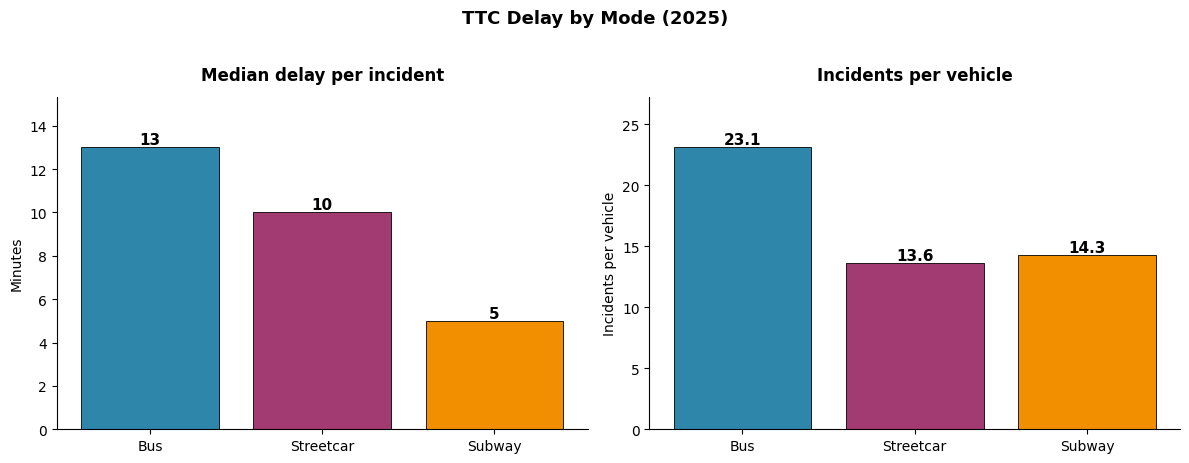

In [ ]:
import matplotlib.pyplot as plt

modes  = ["Bus", "Streetcar", "Subway"]
colors = ["#2E86AB", "#A23B72", "#F18F01"]

med_delay = summary.loc[modes, "median_delay_min"]
inc_veh   = summary.loc[modes, "incidents_per_vehicle"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

def draw(ax, data, title, ylabel, fmt):
    bars = ax.bar(data.index, data.values, color=colors, edgecolor="black", linewidth=0.6)
    for bar, value in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                fmt.format(value), ha="center", va="bottom",
                fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, data.max() * 1.18)

draw(axes[0], med_delay, "Median delay per incident", "Minutes",                "{:.0f}")
draw(axes[1], inc_veh,   "Incidents per vehicle",     "Incidents per vehicle",  "{:,.1f}")

fig.suptitle("TTC Delay by Mode (2025)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**3. Time Analysis**



This section looks at how TTC delay incidents change over time across the network. The analysis explores patterns at multiple levels by month, season, day of week, and hour of day to better understand when the system experiences the most delays.

Beyond simple counts, this section also uses hypothesis testing and distribution analysis to determine whether observed patterns are statistically meaningful rather than random variation. Sometimes trends may look important visually, but the underlying differences are actually quite small once tested statistically. 



The graph below is used to check whether TTC delays follow any noticeable seasonal patterns throughout the year. 



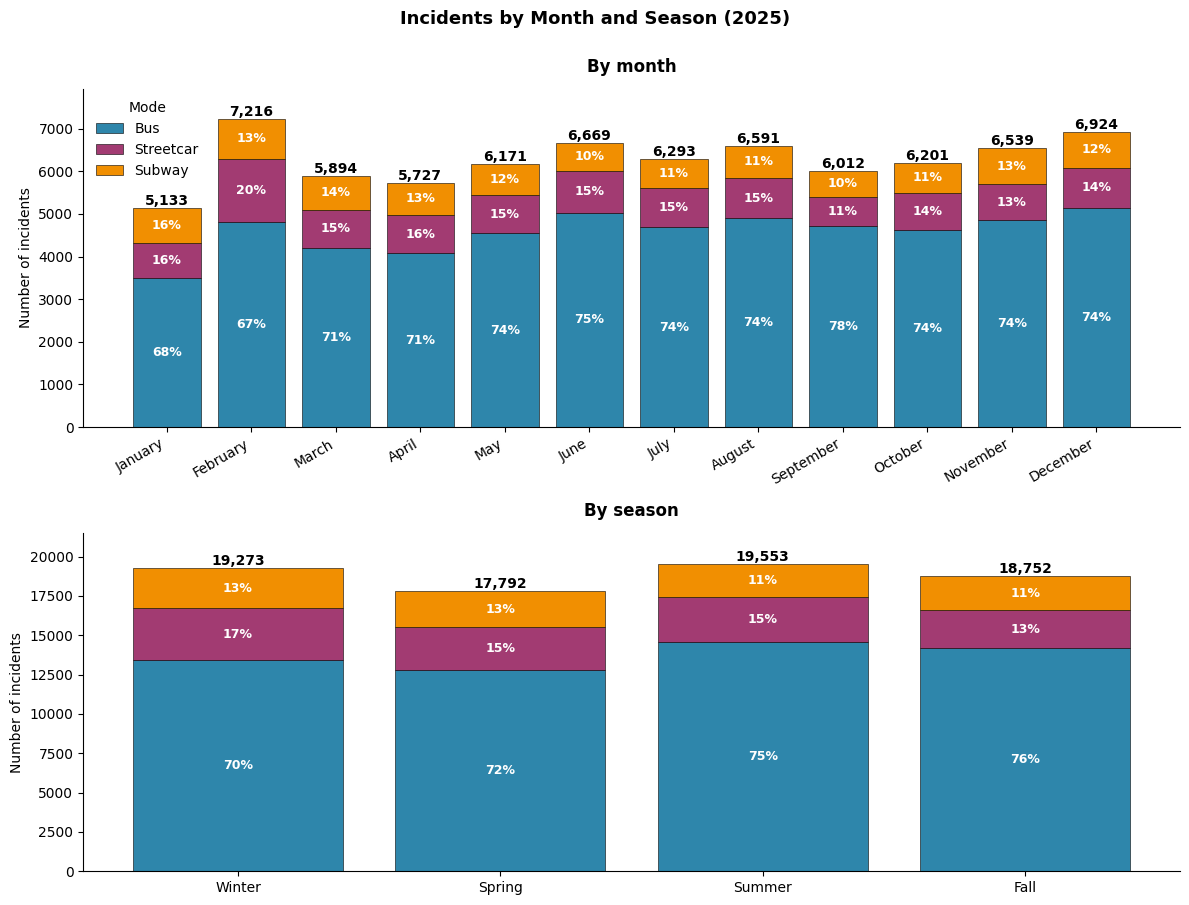

In [ ]:
# Delay incidents by month and by season

import matplotlib.pyplot as plt
import numpy as np

month_order  = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]
season_order = ["Winter", "Spring", "Summer", "Fall"]
mode_order   = ["Bus", "Streetcar", "Subway"]
colors       = {"Bus": "#2E86AB", "Streetcar": "#A23B72", "Subway": "#F18F01"}

monthly = (TTC_delays_2025
    .groupby(["month_name", "mode"], observed=True).size()
    .unstack(fill_value=0).reindex(index=month_order, columns=mode_order))

seasonal = (TTC_delays_2025
    .groupby(["season", "mode"], observed=True).size()
    .unstack(fill_value=0).reindex(index=season_order, columns=mode_order))

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

def stacked_bar(ax, data, title, rotate=False, min_pct_to_label=4.0):
    totals = data.sum(axis=1).values
    bottom = np.zeros(len(data))

    for mode in mode_order:
        values = data[mode].values
        ax.bar(data.index, values, bottom=bottom,
               label=mode, color=colors[mode], edgecolor="black", linewidth=0.4)

        # In-segment percentage labels (skip very small segments to avoid clutter).
        for i, (val, tot) in enumerate(zip(values, totals)):
            if tot > 0:
                pct = 100 * val / tot
                if pct >= min_pct_to_label:
                    ax.text(i, bottom[i] + val / 2, f"{pct:.0f}%",
                            ha="center", va="center",
                            fontsize=9, fontweight="bold", color="white")
        bottom += values

    # Total labels above each bar.
    for i, total in enumerate(totals):
        ax.text(i, total, f"{total:,}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_ylabel("Number of incidents")
    ax.set_ylim(0, totals.max() * 1.10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if rotate:
        ax.tick_params(axis="x", rotation=30)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")

stacked_bar(axes[0], monthly,  "By month",  rotate=True)
stacked_bar(axes[1], seasonal, "By season", rotate=False)
axes[0].legend(title="Mode", frameon=False)

fig.suptitle("Incidents by Month and Season (2025)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

Based on the graph above, delay incidents remain relatively stable throughout the year, with no strong or consistent seasonal pattern across the TTC network. January has the fewest incidents (5,133), while February has the highest (7,216), but monthly totals otherwise remain within a fairly narrow range.

Although delays appear relatively stable month to month, the next graph explores whether TTC incidents are more concentrated on certain days of the week. 



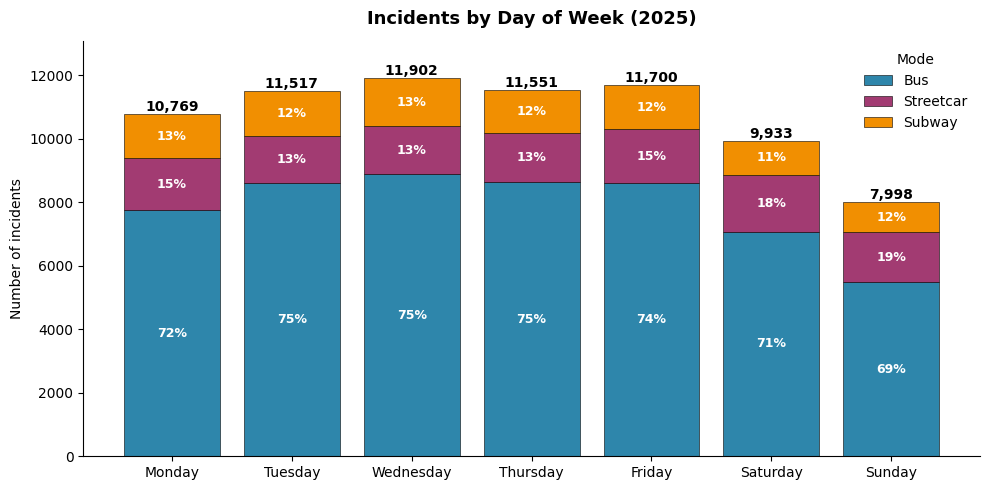

TEST 1 — Chi-square goodness-of-fit (H0: incidents uniform across weekdays)
  chi2 = 1,086.53  df = 6  p ≈ 0.00e+00
  -> REJECT H0 at alpha=0.05

Observed total incidents per day (% vs uniform expectation):
  Monday     10,769  (+0.0%)
  Tuesday    11,517  (+7.0%)
  Wednesday  11,902  (+10.5%)
  Thursday   11,551  (+7.3%)
  Friday     11,700  (+8.7%)
  Saturday    9,933  (-7.7%)
  Sunday      7,998  (-25.7%)



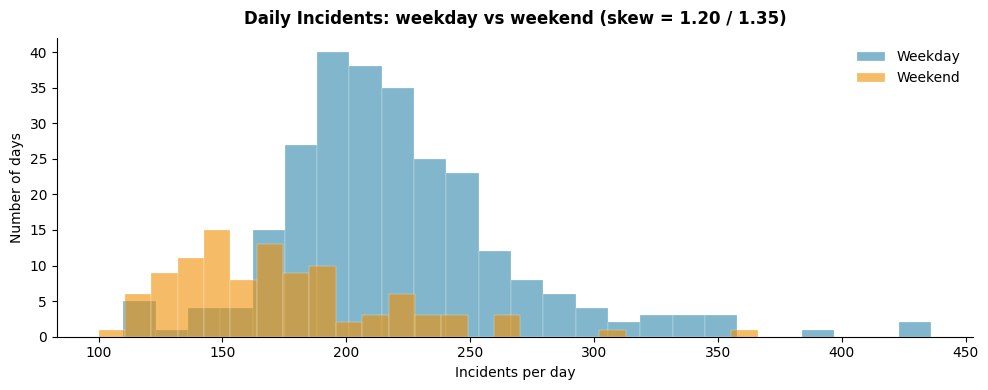

TEST 2 — Mann-Whitney U on daily incident counts (weekday vs weekend)
  Chosen over t-test because the per-day count distribution above is not normal
  (visible skew; Mann-Whitney compares medians/distributions without that assumption).
  Weekdays: n=261  mean=220.1  median=214.0
  Weekends: n=104  mean=172.4  median=167.0
  U = 5,416  p ≈ 0.00e+00
  -> REJECT H0 at alpha=0.05


In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np


def _norm_cdf(z):
    """Standard normal CDF via math.erf."""
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

def chi_square_gof(observed, expected):
    """Chi-square goodness-of-fit. P-value via Wilson-Hilferty approximation
    (accurate for df >= 2). Returns (chi2, df, p)."""
    chi2 = sum((o - e) ** 2 / e for o, e in zip(observed, expected))
    df   = len(observed) - 1
    z    = ((chi2 / df) ** (1/3) - (1 - 2/(9*df))) / math.sqrt(2/(9*df))
    p    = 1 - _norm_cdf(z)
    return chi2, df, p

def mann_whitney_u(x, y):
    """Mann-Whitney U test, two-sided. P-value via normal approximation
    (accurate for n1, n2 >= ~20). Returns (U, p)."""
    n1, n2   = len(x), len(y)
    combined = pd.Series(list(x) + list(y))
    ranks    = combined.rank(method="average")
    R1 = ranks.iloc[:n1].sum()
    U1 = R1 - n1 * (n1 + 1) / 2
    U2 = n1 * n2 - U1
    U  = min(U1, U2)
    mu     = n1 * n2 / 2
    sigma  = math.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z      = (U - mu) / sigma
    p      = 2 * _norm_cdf(z)   # U is min, so z <= 0; two-sided
    return U, p

def skewness(values):
    """Fisher-Pearson skewness (matches pandas.Series.skew bias-adjusted form
    for n large enough; we just use pandas)."""
    return pd.Series(values).skew()

# --- Chart 1: stacked bar by day of week ---

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily = (TTC_delays_2025
    .groupby(["day", "mode"], observed=True).size()
    .unstack(fill_value=0).reindex(index=day_order, columns=mode_order))

fig, ax = plt.subplots(figsize=(10, 5))
totals = daily.sum(axis=1).values
bottom = np.zeros(len(daily))
for mode in mode_order:
    values = daily[mode].values
    ax.bar(daily.index, values, bottom=bottom,
           label=mode, color=colors[mode], edgecolor="black", linewidth=0.4)
    for i, (val, tot) in enumerate(zip(values, totals)):
        if tot > 0 and 100 * val / tot >= 4.0:
            ax.text(i, bottom[i] + val / 2, f"{100*val/tot:.0f}%",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold", color="white")
    bottom += values
for i, t in enumerate(totals):
    ax.text(i, t, f"{t:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Incidents by Day of Week (2025)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of incidents")
ax.set_ylim(0, totals.max() * 1.10)
ax.legend(title="Mode", frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

# --- Test 1: chi-square goodness-of-fit ---
expected         = [totals.sum() / 7] * 7
chi2, df, pval   = chi_square_gof(totals, expected)
print(f"TEST 1 — Chi-square goodness-of-fit (H0: incidents uniform across weekdays)")
print(f"  chi2 = {chi2:,.2f}  df = {df}  p ≈ {pval:.2e}")
print(f"  -> {'REJECT H0' if pval < 0.05 else 'cannot reject H0'} at alpha=0.05\n")
print("Observed total incidents per day (% vs uniform expectation):")
for d, n in zip(day_order, totals):
    diff = 100 * (n - expected[0]) / expected[0]
    print(f"  {d:10s} {n:>6,}  ({diff:+.1f}%)")
print()

# --- Build per-day counts ---
per_day = (
    TTC_delays_2025
    .assign(date_only=TTC_delays_2025["date"].dt.date)
    .groupby(["date_only", "is_weekend"], observed=True).size()
    .reset_index(name="incidents")
)
weekday_counts = per_day.loc[~per_day["is_weekend"], "incidents"].values
weekend_counts = per_day.loc[ per_day["is_weekend"], "incidents"].values

# --- Chart 2: distribution of daily counts — justification for Mann-Whitney ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(weekday_counts, bins=25, alpha=0.6, label="Weekday",
        color="#2E86AB", edgecolor="white", linewidth=0.3)
ax.hist(weekend_counts, bins=25, alpha=0.6, label="Weekend",
        color="#F18F01", edgecolor="white", linewidth=0.3)
wk_skew = skewness(weekday_counts)
we_skew = skewness(weekend_counts)
ax.set_title(f"Daily Incidents: weekday vs weekend "
             f"(skew = {wk_skew:.2f} / {we_skew:.2f})",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Incidents per day")
ax.set_ylabel("Number of days")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

# --- Test 2: Mann-Whitney U ---
U, pval2 = mann_whitney_u(weekday_counts, weekend_counts)
print(f"TEST 2 — Mann-Whitney U on daily incident counts (weekday vs weekend)")
print(f"  Chosen over t-test because the per-day count distribution above is not normal")
print(f"  (visible skew; Mann-Whitney compares medians/distributions without that assumption).")
print(f"  Weekdays: n={len(weekday_counts):>3}  "
      f"mean={weekday_counts.mean():.1f}  median={np.median(weekday_counts):.1f}")
print(f"  Weekends: n={len(weekend_counts):>3}  "
      f"mean={weekend_counts.mean():.1f}  median={np.median(weekend_counts):.1f}")
print(f"  U = {U:,.0f}  p ≈ {pval2:.2e}")
print(f"  -> {'REJECT H0' if pval2 < 0.05 else 'cannot reject H0'} at alpha=0.05")

**Graph 1: Incidents by Day of Week**

1. Delay incidents are not evenly distributed across the week. Based on the graph above, weekdays consistently record more incidents than weekends, with Sunday standing out as the quietest day overall.
2. A chi-squared test confirms that these differences are statistically significant rather than random variation.

**Graph 2: Daily Incidents: weekday vs weekend**

1. To compare weekday and weekend incident levels more directly, a Mann–Whitney U test was used instead of a standard t-test since daily incident counts were positively skewed, meaning a small number of unusually high-delay days pulled the distribution away from normality.
2. The results strongly suggest that weekdays place much heavier pressure on the TTC network, averaging roughly 28% more incidents per day than weekends, likely driven by commuter demand and higher passenger volumes during the work week.

While delays are clearly more concentrated on weekdays, the next graph explores how incidents change throughout the day and when the TTC network is under the most pressure. 



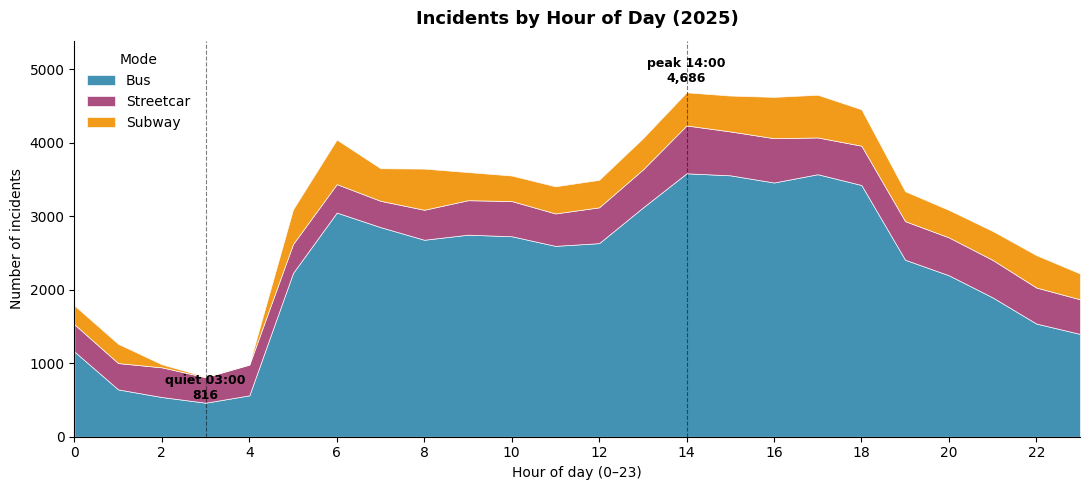

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

hourly = (TTC_delays_2025
    .groupby(["hour", "mode"], observed=True).size()
    .unstack(fill_value=0).reindex(index=range(24), columns=mode_order, fill_value=0))

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(hourly.index,
             [hourly[m].values for m in mode_order],
             labels=mode_order,
             colors=[colors[m] for m in mode_order],
             edgecolor="white", linewidth=0.5, alpha=0.9)

# Annotate peak and quiet hours on the chart itself.
hourly_total = hourly.sum(axis=1)
peak_hour    = int(hourly_total.idxmax())
quiet_hour   = int(hourly_total.idxmin())
ax.axvline(peak_hour,  color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(quiet_hour, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.text(peak_hour, hourly_total.max() * 1.02,
        f"peak {peak_hour:02d}:00\n{hourly_total[peak_hour]:,}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.text(quiet_hour, hourly_total.max() * 0.10,
        f"quiet {quiet_hour:02d}:00\n{hourly_total[quiet_hour]:,}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Incidents by Hour of Day (2025)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of incidents")
ax.set_xlabel("Hour of day (0–23)")
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.set_ylim(0, hourly_total.max() * 1.15)
ax.legend(title="Mode", frameon=False, loc="upper left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

From the graph above, the day can roughly be broken down into the following time periods: 



1. **1–4 AM:**, The network is at its quietest, with incidents falling to their daily low around 3 AM. This lines up with reduced overnight service and the subway shutdown period between roughly 2–4 AM. 
2. **4–6 AM:**, Incidents rise sharply as TTC service ramps up for the morning commute, with a noticeable jump by 6 AM. 
3. **6 AM–12 PM:**, Delay incidents fall below the 6 AM peak and remain relatively steady through the morning and late morning, with only moderate fluctuations. 
4. **12–2 PM:**, Another clear rise period appears in the early afternoon, leading into the peak daily incident count at 2 PM.
5. **2–6 PM:**, Incident levels remain consistently high throughout the afternoon and evening rush-hour period before gradually declining later in the evening. 
6. 6-11 PM: Delays steadily decline hour-by-hour, with the sharpest drop occurring between 6 and 7 PM. 
7. **Limitation:**, This dataset does not include ridership or service-frequency data. It would be useful to compare incidents against passenger volume or the number of vehicles in operation at each hour to better understand whether these spikes simply reflect heavier rush-hour usage, which appears likely.



The final graph in this section looks at the distribution of delay duration across each mode of transport. 



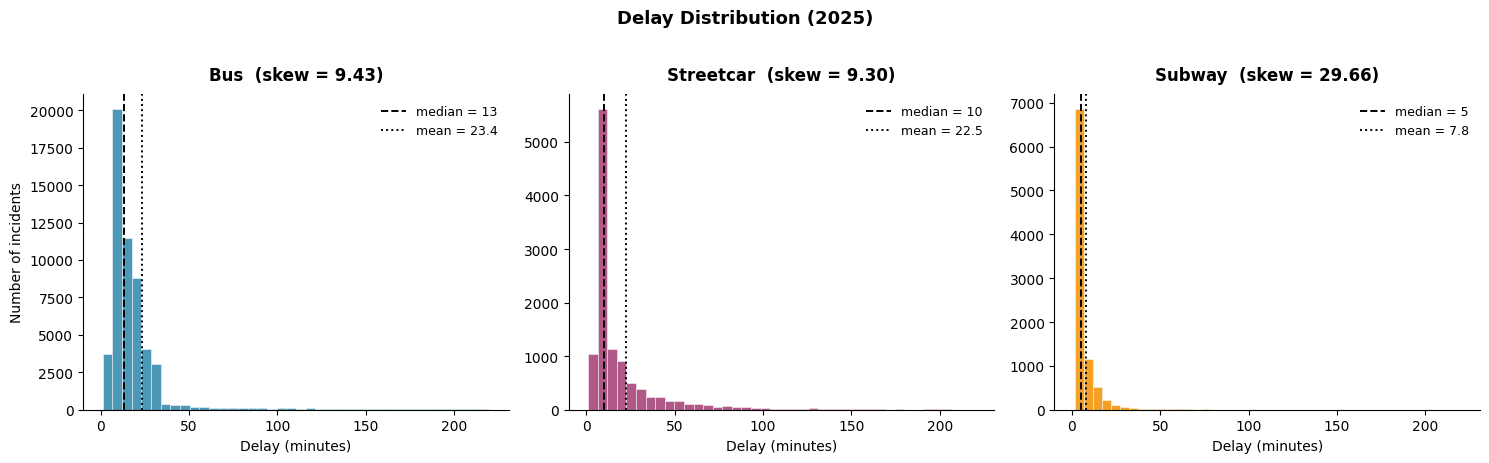

In [ ]:
import matplotlib.pyplot as plt

cap = TTC_delays_2025["min_delay"].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for ax, mode in zip(axes, mode_order):
    data = TTC_delays_2025.loc[TTC_delays_2025["mode"] == mode, "min_delay"]
    skew = data.skew()
    med  = data.median()
    mean = data.mean()

    ax.hist(data[data <= cap], bins=40,
            color=colors[mode], edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(med,  color="black", linestyle="--", linewidth=1.4, label=f"median = {med:.0f}")
    ax.axvline(mean, color="black", linestyle=":",  linewidth=1.4, label=f"mean = {mean:.1f}")

    ax.set_title(f"{mode}  (skew = {skew:.2f})", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Delay (minutes)")
    ax.set_ylabel("Number of incidents" if mode == mode_order[0] else "")
    ax.legend(frameon=False, fontsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

fig.suptitle(f"Delay Distribution (2025)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

The graph shows that all three modes of transport have heavily right-skewed distributions, meaning most delays are fairly short while a small number of major incidents pull the average upward. That is why this analysis uses median delay instead of mean when describing a “typical” delay.

The subway is the most extreme example, with most delays under 10 minutes but a few very large incidents creating a long tail in the distribution.



**4. Worst Routes**



This section looks at which specific routes and vehicles create the most disruption across the TTC network. The focus is on which routes have the most delays, and whether recurring problems seem tied to individual vehicles or the busy routes they operate on. 



The first graph below looks at the worst 15 routes by total delay hours.



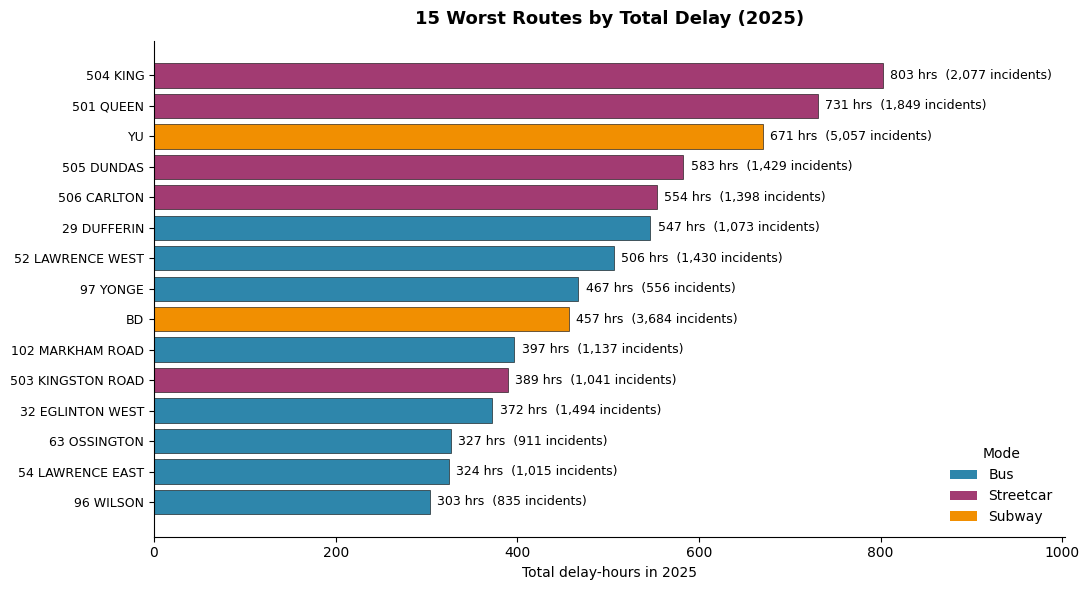

In [ ]:
worst_routes = (
    TTC_delays_2025
    .groupby(["line", "mode"], observed=True)["min_delay"]
    .agg(total_delay_min="sum", incidents="count")
    .reset_index()
    .assign(total_delay_hours=lambda d: (d["total_delay_min"] / 60).round(1))
    .sort_values("total_delay_hours", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [colors[m] for m in worst_routes["mode"]]
y = range(len(worst_routes))[::-1]  # so #1 is at top

ax.barh(y, worst_routes["total_delay_hours"], color=bar_colors,
        edgecolor="black", linewidth=0.4)

for i, (hours, inc) in enumerate(zip(worst_routes["total_delay_hours"],
                                     worst_routes["incidents"])):
    ax.text(hours + max(worst_routes["total_delay_hours"]) * 0.01,
            y[i], f"{hours:,.0f} hrs  ({inc:,} incidents)",
            va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(worst_routes["line"], fontsize=9)
ax.set_xlabel("Total delay-hours in 2025")
ax.set_title("15 Worst Routes by Total Delay (2025)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, worst_routes["total_delay_hours"].max() * 1.25)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Custom legend for mode colors.
from matplotlib.patches import Patch
handles = [Patch(facecolor=colors[m], label=m) for m in mode_order]
ax.legend(handles=handles, title="Mode", frameon=False, loc="lower right")

plt.tight_layout(); plt.show()

The graph gives us some interesting findings:

Streetcar routes dominate the top of the rankings, with 4 of the 5 worst routes by total rider time lost being streetcars, including the 504 King and 501 Queen. While buses create the most disruption across the network overall, streetcars seem to have the biggest route-level reliability problems.

This is especially important because the 504 and 501 are two of the TTC’s busiest and most important surface routes, carrying tens of thousands of riders through downtown every day. Unlike many other streetcars, there is no east-west subway running alongside them, meaning delays on these lines leave riders with very limited alternatives.

With a 2017 article describing it best: _"There's a good rule of thumb when considering the King streetcar for shorter trips: if it's not in sight, just start walking. You'll probably get there faster."  _It's crazy to think this is still true in 2025.

The subway lines also rank highly, although this is partly structural since the entire subway system consists of only 3 lines, so all subway delays are concentrated onto a very small number of routes. 

Source for quote: [The Globe and Mail — "Toronto pilot project looks to make King Street rapid transit live up to its name" (May 12, 2017) ](https://www.theglobeandmail.com/news/toronto/toronto-pilot-project-looks-to-make-king-street-rapid-transit-live-up-to-itsname/article34976015/#:~:text=There's%20a%20good%20rule%20of,You'll%20probably%20get%20there%20faster.)



The second graph below looks at individual vehicles that have logged the most incidents.



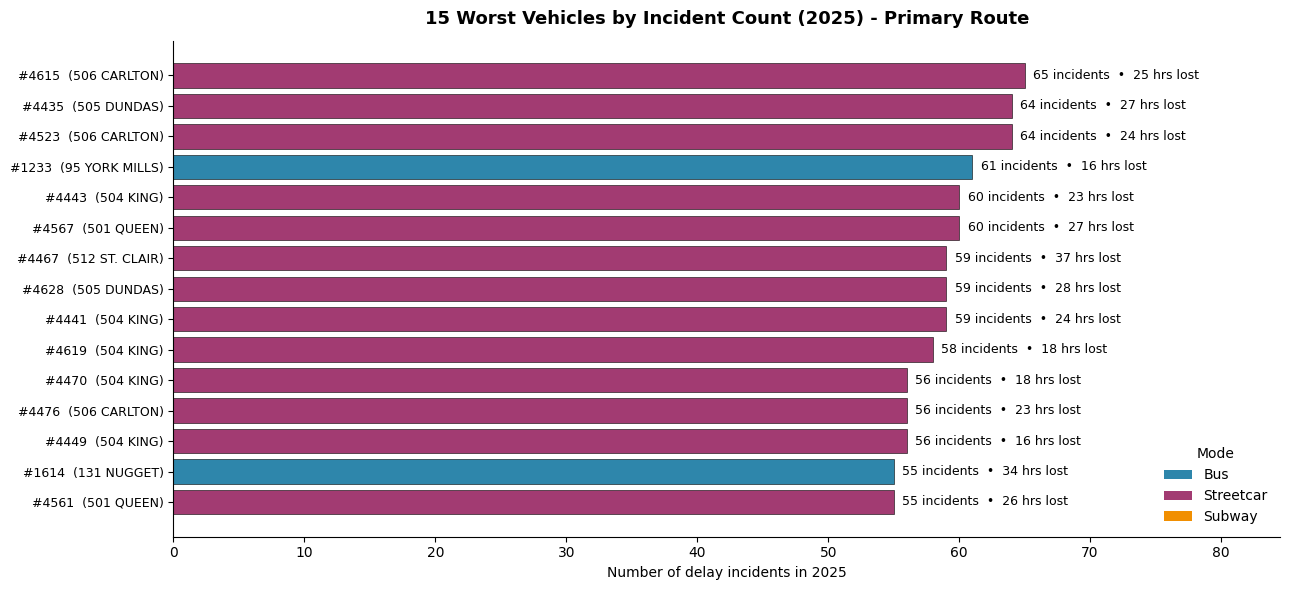

,vehicle,mode,incidents,total_delay_hours,top_route,top_route_share,n_routes_served
0,4615,Streetcar,65,25.2,506 CARLTON,29,11
1,4435,Streetcar,64,26.7,505 DUNDAS,39,10
2,4523,Streetcar,64,24.4,506 CARLTON,27,10
3,1233,Bus,61,15.7,95 YORK MILLS,20,16
4,4443,Streetcar,60,23.1,504 KING,20,10
5,4567,Streetcar,60,26.8,501 QUEEN,58,7
6,4467,Streetcar,59,37.2,512 ST. CLAIR,27,10
7,4628,Streetcar,59,28.5,505 DUNDAS,24,10
8,4441,Streetcar,59,23.7,504 KING,22,10
9,4619,Streetcar,58,18.1,504 KING,31,10


In [ ]:

def _top_route(s):
    vc = s.dropna().value_counts()
    return vc.index[0] if len(vc) > 0 else "—"

def _top_route_share(s):
    vc = s.dropna().value_counts()
    return (vc.iloc[0] / len(s)) if len(vc) > 0 else 0.0

route_context = (
    TTC_delays_2025[TTC_delays_2025["vehicle"] != 0]
    .groupby("vehicle")
    .agg(
        top_route        = ("line", _top_route),
        top_route_share  = ("line", _top_route_share),
        n_routes_served  = ("line", "nunique"),
    )
    .reset_index()
)

worst_vehicles = (
    TTC_delays_2025[TTC_delays_2025["vehicle"] != 0]
    .groupby(["vehicle", "mode"], observed=True)
    .agg(incidents=("id", "count"),
         total_delay_min=("min_delay", "sum"))
    .reset_index()
    .assign(total_delay_hours=lambda d: (d["total_delay_min"] / 60).round(1))
    .sort_values("incidents", ascending=False)
    .head(15)
    .merge(route_context, on="vehicle", how="left")
    .assign(top_route_share=lambda d: (d["top_route_share"] * 100).round(0).astype(int))
    .reset_index(drop=True)
)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = [colors[m] for m in worst_vehicles["mode"]]
y = range(len(worst_vehicles))[::-1]

ax.barh(y, worst_vehicles["incidents"], color=bar_colors,
        edgecolor="black", linewidth=0.4)

for i, row in worst_vehicles.iterrows():
    label = f"{row['incidents']} incidents  •  {row['total_delay_hours']:,.0f} hrs lost"
    ax.text(row["incidents"] + max(worst_vehicles["incidents"]) * 0.01,
            y[i], label, va="center", fontsize=9)

yticklabels = [
    f"#{row['vehicle']}  ({row['top_route']})"
    for _, row in worst_vehicles.iterrows()
]
ax.set_yticks(y)
ax.set_yticklabels(yticklabels, fontsize=9)
ax.set_xlabel("Number of delay incidents in 2025")
ax.set_title("15 Worst Vehicles by Incident Count (2025) - Primary Route",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, worst_vehicles["incidents"].max() * 1.30)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

handles = [Patch(facecolor=colors[m], label=m) for m in mode_order]
ax.legend(handles=handles, title="Mode", frameon=False, loc="lower right")

plt.tight_layout(); plt.show()

worst_vehicles[[
    "vehicle", "mode", "incidents", "total_delay_hours",
    "top_route", "top_route_share", "n_routes_served"
]]

We see from the graph that streetcars dominate the worst-vehicle rankings, with 13 of the top 15 vehicles coming from the streetcar fleet. Most are heavily tied to the same major downtown routes identified earlier, especially the 504 King, 506 Carlton, 505 Dundas, and 501 Queen.

At the same time, these vehicles are not limited to a single route. Many operate across 7–18 different routes, suggesting this is less about a few “bad vehicles” and perhaps more about the routes they run on. This is something I explore further in the final section below.



**5. Reason for Incidents (Streetcars)**



The final section of this analysis looks at what is actually causing TTC streetcar delays. Instead of focusing on when and where incidents happen, the goal here is to understand the underlying reasons behind them and whether the worst downtown routes experience a different mix of problems than the rest of the network.

The TTC streetcar dataset contains 85 different delay codes, many of which are highly detailed and difficult to interpret directly. To make the analysis more usable, the codes were grouped into five broader categories:

- **ET**, — Equipment / vehicle problems 
- **MT**, — Movement and operations 
- **TT**, — Operator or transportation-related issues 
- **PT**, — Infrastructure and track issues 
- **ST**, — Safety and security incidents 

The analysis compares which causes are most common, which create the longest delays, and whether the patterns seen on the worst-performing routes are different from the rest of the streetcar system.



The graph below shows us the frequency and severity of streetcar incidents by reason. Please refer to the table above or below the graph as a key for the delay codes.



In [ ]:
valid_prefixes = {"ET", "MT", "TT", "PT", "ST"}

streetcar_delays = TTC_delays_2025[TTC_delays_2025["mode"] == "Streetcar"].copy()
streetcar_delays["reason_family"] = (
    streetcar_delays["code"].str[:2]
    .where(lambda s: s.isin(valid_prefixes))
)

streetcar_delays.head()

,id,date,line,time,day,location,code,min_delay,vehicle,mode,hour,location_clean,month,month_name,is_weekend,season,reason_family
69037,1,2025-01-01,504 KING,02:10,Wednesday,KING AND PARLIAMENT,MTSAN,10,4569,Streetcar,2,AND KING PARLIAMENT,1,January,False,Winter,MT
69038,2,2025-01-01,506 CARLTON,02:50,Wednesday,COLLEGE AND HURON,MTAFR,34,4480,Streetcar,2,AND COLLEGE HURON,1,January,False,Winter,MT
69039,3,2025-01-01,504 KING,03:11,Wednesday,KING AND QUEEN EAST,MTIE,15,4629,Streetcar,3,AND EAST KING QUEEN,1,January,False,Winter,MT
69040,4,2025-01-01,501 QUEEN,05:14,Wednesday,QUEEN AND DUFFERIN,MTAFR,36,4455,Streetcar,5,AND DUFFERIN QUEEN,1,January,False,Winter,MT
69041,5,2025-01-01,504 KING,06:14,Wednesday,LESLIE CARHOUSE,MTVIS,10,4483,Streetcar,6,CARHOUSE LESLIE,1,January,False,Winter,MT


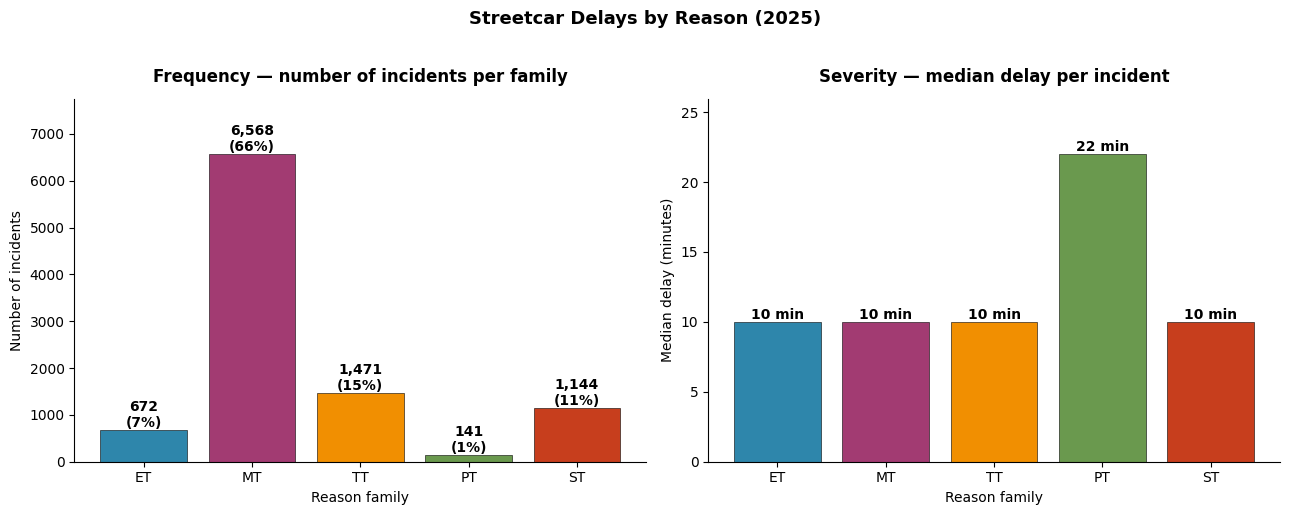

,reason_name,incidents,median_delay,total_hours,pct_of_incidents
reason_family,,,,,
ET,Equipment,672,10.0,169.2,6.7
MT,Movement / Operations,6568,10.0,2749.8,65.7
TT,Transportation / Operator,1471,10.0,596.9,14.7
PT,Plant / Infrastructure,141,22.0,115.1,1.4
ST,Safety / Security,1144,10.0,356.8,11.4


In [ ]:
import matplotlib.pyplot as plt

family_order  = ["ET", "MT", "TT", "PT", "ST"]
family_names  = {
    "ET": "Equipment",
    "MT": "Movement / Operations",
    "TT": "Transportation / Operator",
    "PT": "Plant / Infrastructure",
    "ST": "Safety / Security",
}
family_colors = {
    "ET": "#2E86AB",
    "MT": "#A23B72",
    "TT": "#F18F01",
    "PT": "#6A994E",
    "ST": "#C73E1D",
}

agg = (
    streetcar_delays.dropna(subset=["reason_family"])
    .groupby("reason_family")
    .agg(incidents=("id", "count"),
         median_delay=("min_delay", "median"),
         total_hours=("min_delay", lambda s: s.sum() / 60))
    .reindex(family_order)
)

agg["pct_of_incidents"] = (100 * agg["incidents"] / agg["incidents"].sum()).round(1)
agg = agg.round({"median_delay": 1, "total_hours": 1})
agg.insert(0, "reason_name", agg.index.map(family_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(agg.index, agg["incidents"],
                    color=[family_colors[f] for f in agg.index],
                    edgecolor="black", linewidth=0.4)
for bar, n, pct in zip(bars1, agg["incidents"], agg["pct_of_incidents"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{n:,}\n({pct:.0f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Frequency — number of incidents per family",
                  fontsize=12, fontweight="bold", pad=12)
axes[0].set_ylabel("Number of incidents")
axes[0].set_ylim(0, agg["incidents"].max() * 1.18)

bars2 = axes[1].bar(agg.index, agg["median_delay"],
                    color=[family_colors[f] for f in agg.index],
                    edgecolor="black", linewidth=0.4)
for bar, val in zip(bars2, agg["median_delay"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{val:.0f} min",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_title("Severity — median delay per incident",
                  fontsize=12, fontweight="bold", pad=12)
axes[1].set_ylabel("Median delay (minutes)")
axes[1].set_ylim(0, agg["median_delay"].max() * 1.18)

for ax in axes:
    ax.set_xlabel("Reason family")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

fig.suptitle("Streetcar Delays by Reason (2025)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

agg

The graph tells a very straightforward story: Movement / Operations (MT) dominates streetcar delays, accounting for roughly 66% of all incidents.

Interestingly, most delay types have almost the exact same “typical” delay length. ET, MT, TT, and ST incidents all have a median delay of around 10 minutes, suggesting that once a streetcar disruption happens, recovery times are fairly similar regardless of the specific cause.

The one major exception is PT (Plant / Infrastructure) incidents. These delays have a much higher median duration of 22 minutes, but they are also extremely rare, making up only about 1% of all incidents.

Overall, the biggest reliability issue for the streetcar network is not unusually severe delays, but rather the sheer volume of everyday operational incidents happening across the system.



In the final two visuals below, we look to examine if our "worst routes" from above exhibit different behaviours to the rest of the streetcars.



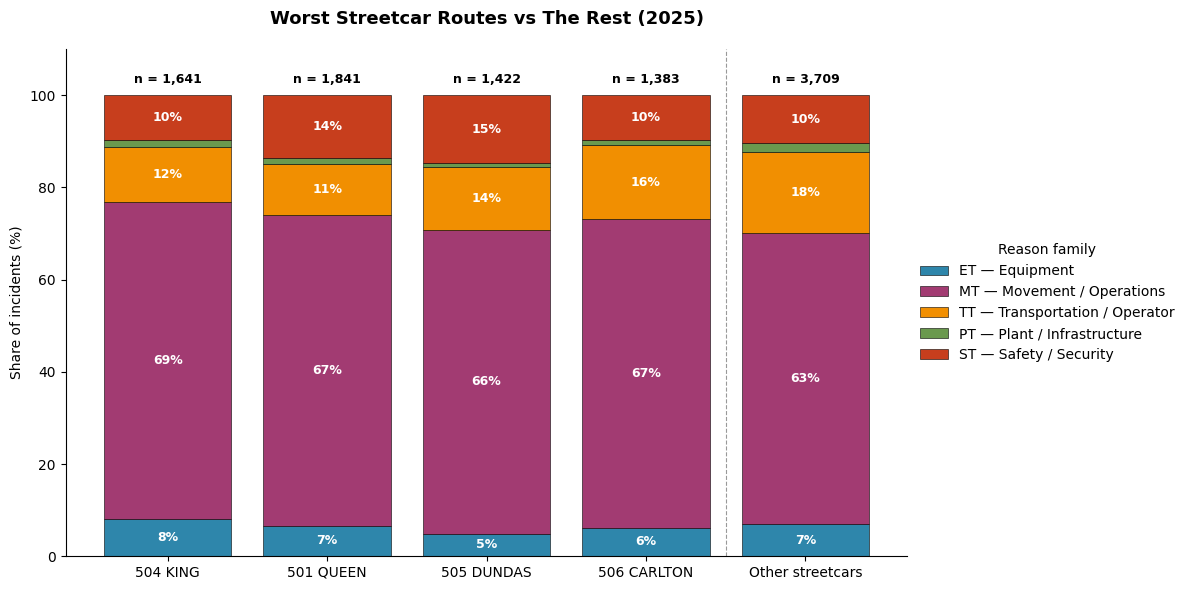


Median delay — worst routes vs streetcar baselines:


,incidents,median_delay_min
line,,
504 KING,2077,10.0
501 QUEEN,1849,10.0
505 DUNDAS,1429,10.0
506 CARLTON,1398,10.0
All streetcar,11233,10.0
Other streetcars,4480,10.0


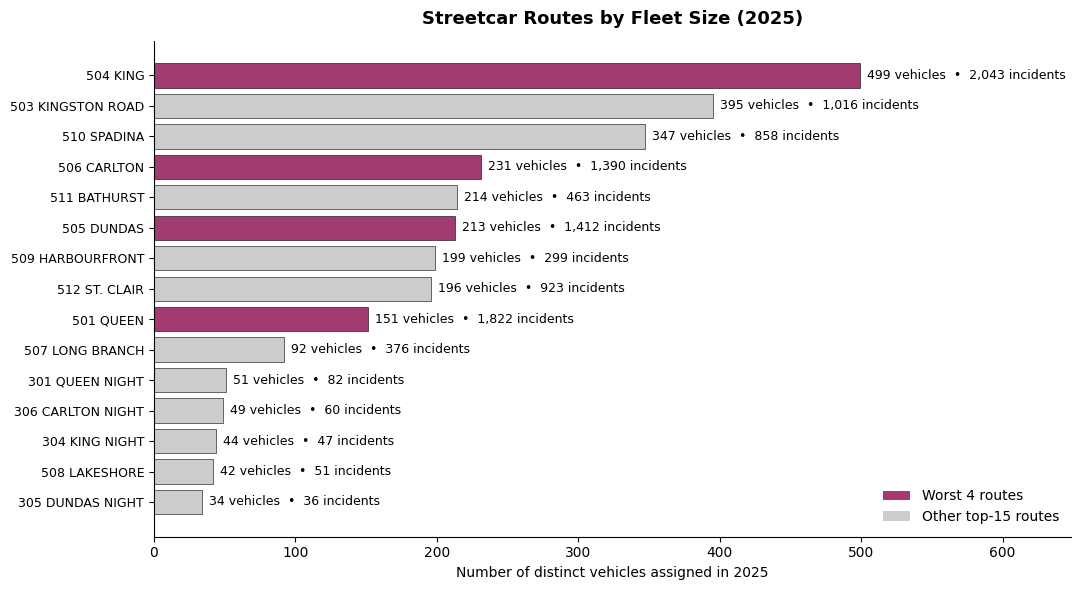

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

worst_routes = ["504 KING", "501 QUEEN", "505 DUNDAS", "506 CARLTON"]
clean = streetcar_delays.dropna(subset=["reason_family"])

route_counts = (
    clean[clean["line"].isin(worst_routes)]
    .groupby(["line", "reason_family"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=worst_routes, columns=family_order, fill_value=0)
)

# Baseline EXCLUDES the worst 4 routes — the comparison group is the rest
# of the streetcar fleet, so the bars aren't partially comparing against themselves.
baseline = (
    clean[~clean["line"].isin(worst_routes)]
    .groupby("reason_family").size()
    .reindex(family_order, fill_value=0)
    .to_frame().T
)
baseline.index = ["Other streetcars"]

combined  = pd.concat([route_counts, baseline])
totals    = combined.sum(axis=1)
pct       = combined.div(totals, axis=0) * 100

# --- Chart: 100%-stacked bar ---
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pct))
for family in family_order:
    ax.bar(pct.index, pct[family], bottom=bottom,
           color=family_colors[family], edgecolor="black", linewidth=0.4,
           label=f"{family} — {family_names[family]}")
    for i, val in enumerate(pct[family].values):
        if val >= 3:
            ax.text(i, bottom[i] + val / 2, f"{val:.0f}%",
                    ha="center", va="center", color="white",
                    fontsize=9, fontweight="bold")
    bottom += pct[family].values

for i, t in enumerate(totals):
    ax.text(i, 102, f"n = {t:,}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.axvline(3.5, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_title("Worst Streetcar Routes vs The Rest (2025)",
             fontsize=13, fontweight="bold", pad=18)
ax.set_ylabel("Share of incidents (%)")
ax.set_ylim(0, 110)
ax.legend(title="Reason family", frameon=False,
          loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


# --- Median delay: 4 worst routes vs all-streetcar baseline ---
delay_compare = (
    streetcar_delays[streetcar_delays["line"].isin(worst_routes)]
    .groupby("line")["min_delay"]
    .agg(incidents="count", median_delay_min="median")
    .reindex(worst_routes)
)

other_streetcars = streetcar_delays[~streetcar_delays["line"].isin(worst_routes)]

delay_compare.loc["All streetcar"] = [
    len(streetcar_delays),
    streetcar_delays["min_delay"].median(),
]
delay_compare.loc["Other streetcars"] = [
    len(other_streetcars),
    other_streetcars["min_delay"].median(),
]

delay_compare["median_delay_min"] = delay_compare["median_delay_min"].round(1)
delay_compare["incidents"] = delay_compare["incidents"].astype(int)
print("\nMedian delay — worst routes vs streetcar baselines:")
display(delay_compare)

# --- Top 15 streetcar routes by number of distinct vehicles ---
vehicles_per_route = (
    streetcar_delays[streetcar_delays["vehicle"] != 0]
    .groupby("line")
    .agg(n_vehicles=("vehicle", "nunique"),
         incidents=("id", "count"))
    .sort_values("n_vehicles", ascending=False)
    .head(15)
    .reset_index()
)

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(11, 6))
y = range(len(vehicles_per_route))[::-1]
bar_colors = [
    "#A23B72" if r in worst_routes else "#CCCCCC"
    for r in vehicles_per_route["line"]
]
ax.barh(y, vehicles_per_route["n_vehicles"], color=bar_colors,
        edgecolor="black", linewidth=0.4)

for i, row in vehicles_per_route.iterrows():
    ax.text(row["n_vehicles"] + max(vehicles_per_route["n_vehicles"]) * 0.01,
            y[i], f"{row['n_vehicles']} vehicles  •  {row['incidents']:,} incidents",
            va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(vehicles_per_route["line"], fontsize=9)
ax.set_xlabel("Number of distinct vehicles assigned in 2025")
ax.set_title("Streetcar Routes by Fleet Size (2025)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, vehicles_per_route["n_vehicles"].max() * 1.30)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(handles=[Patch(facecolor="#A23B72", label="Worst 4 routes"),
                   Patch(facecolor="#CCCCCC", label="Other top-15 routes")],
          frameon=False, loc="lower right")
plt.tight_layout(); plt.show()


**Graph 1: Worst Streetcar Routes**

We see that out of 79 streetcar routes in the network, just 4 routes  504 King, 501 Queen, 505 Dundas, and 506 Carlton — account for roughly 60% of all streetcar delay incidents.

The types of delays on these four routes are almost identical to the overall streetcar network. MT incidents dominate everywhere, and the remaining cause categories are distributed pretty similarly across routes, suggesting these routes don’t actually have unique operational problems.

The median delay per incident on these routes also matches the streetcar network baseline of 10 minutes. In other words, delays on these routes are not necessarily worse individually, there are just far more of them.

**Graph 2: Top 15 Streetcar Routes by Fleet Size**

The most likely explanation is simply volume. While ridership data is not available in this dataset, these four routes are widely known as some of the TTC’s busiest ones. Rough fleet size analysis also shows that these routes rank among the top 10 in terms of vehicle count. _Though it should be noted that this is technically a measure of all vehicles that have operated on this route and had an accident._

It is reasonable to assume that with more vehicles running on these routes, they just have more total incidents. While it does appear that each vehicle on our top 4 routes has more incidents per vehicle, we don't have data for how many times the vehicle operates on the route, so we can only assume its because of how often the vehicles need to operate and how many people use them.

While it's unfortunate for riders that some of the most popular streetcar routes have the most delays, their being popular is probably the reason in itself.



**6. Conclusions & Further Exploration**



This project explored TTC delay incidents across buses, streetcars, and subways to better understand where delays happen, when the network experiences the most pressure, and which parts of the system create the biggest rider impact.

Several conclusions can be made from the analysis:

- buses generate the largest overall rider impact across the network 
- delay incidents are heavily concentrated during weekday commuting hours 
- a relatively small number of streetcar routes account for a disproportionate share of incidents 
- most problems appear to come from the constant accumulation of smaller operational issues rather than isolated catastrophic failures 

One of the more interesting findings was that the busiest streetcar routes did not appear operationally unique in terms of delay causes or severity. Instead, the strongest explanation for their high incident totals appears to simply be volume: more vehicles, more service, and denser routes creating more opportunities for disruption.

The analysis also highlighted several limitations in the dataset itself. Ridership and service frequency data were not available, making it difficult to fully separate operational problems from periods of naturally heavier system usage.



One area that I think would be very exciting to explore further would be:

1. **Impact of major events on TTC delays: **,Toronto hosts concerts, sports games, festivals, and large events almost every week, many of which place additional pressure on the TTC network. In response, the TTC often runs extra service during these periods. It would be interesting to examine whether those adjustments are actually effective by identifying major event periods and comparing delay patterns before, during, and after them. 

